# 4.4. 컴퓨터로 풀어보기

In [ ]:
import numpy as np
from scipy.constants import hbar, m_e, e, h


def second_derivative_matrix(N, dx):
    """0.2.3절에서 만든 그 행렬"""
    return (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


def solve(N, L, potential=None):
    """길이 L인 구간을 N개 격자로 나눠 Schrödinger 방정식을 푼다"""
    dx = L / (N + 1)
    x = np.linspace(0, L, N + 2)[1:-1]  # 양 끝에서는 psi=0 이므로 제외
    V = np.zeros(N) if potential is None else potential(x)

    H = -(hbar**2) / (2 * m_e) * second_derivative_matrix(N, dx) + np.diag(V)
    E, psi = np.linalg.eigh(H)

    return x, E / e, psi

In [3]:
L = 1e-9


def exact(n, L=L):
    return n**2 * h**2 / (8 * m_e * L**2) / e


print(f"{'N':>7} " + "".join(f"{'n='+str(n):>11}" for n in range(1, 5)))
for N in [10, 50, 200, 1000]:
    x, E, psi = solve(N, L)
    print(f"{N:7d} " + "".join(f"{E[n-1]:11.5f}" for n in range(1, 5)))
print(f"{'해석해':>5} " + "".join(f"{exact(n):11.5f}" for n in range(1, 5)))

      N         n=1        n=2        n=3        n=4
     10     0.37348    1.46367    3.18224    5.38997
     50     0.37591    1.50222    3.37465    5.98610
    200     0.37602    1.50400    3.38365    6.01452
   1000     0.37603    1.50412    3.38425    6.01640
  해석해     0.37603    1.50412    3.38427    6.01648


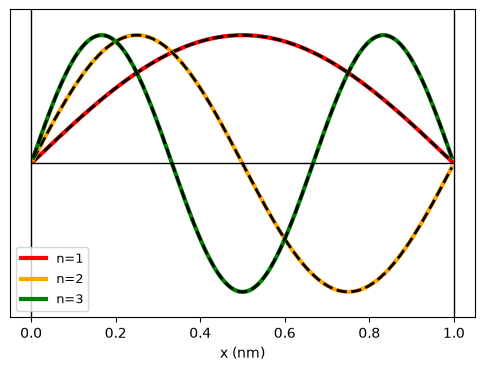

In [17]:
import matplotlib.pyplot as plt

x, E, psi = solve(200, L)

fig, ax = plt.subplots(figsize=(6, 4))
for n, col in zip([1, 2, 3], ["red", "orange", "green"]):
    v = psi[:, n - 1]
    if v[len(v) // 4] < 0:  # 부호 관례를 맞춰준다
        v = -v
    ax.plot(x * 1e9, v / np.abs(v).max(), lw=3, color=col, label=f"n={n}")
    ax.plot(
        x * 1e9, np.sin(n * np.pi * x / L), ls="--", lw=2, color="black", alpha=1
    )

ax.set_xlabel("x (nm)")
ax.hlines(0, 0, L * 1e9, color="black", lw=1)
ax.vlines([0, L * 1e9], -1.2, 1.2, color="black", lw=1)
ax.set_ylim(-1.2, 1.2)
ax.set_yticks([])
ax.legend(fontsize=9)
plt.show()

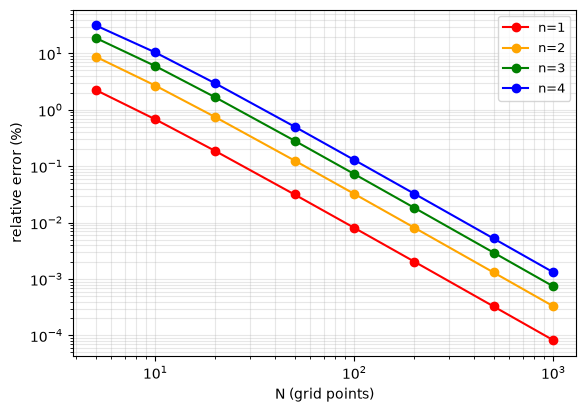

In [19]:
Ns = [5, 10, 20, 50, 100, 200, 500, 1000]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for n, col in zip([1, 2, 3, 4], ["red", "orange", "green", "blue"]):
    errors = [abs(solve(N, L)[1][n - 1] - exact(n)) / exact(n) * 100 for N in Ns]
    ax.loglog(Ns, errors, "o-", color=col, label=f"n={n}")

ax.set_xlabel("N (grid points)")
ax.set_ylabel("relative error (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.show()

In [20]:
for N in [10, 50, 200]:
    x, E, psi = solve(N, L)
    line = "  ".join(
        f"n={n}: {abs(E[n-1]-exact(n))/exact(n)*100:7.4f}%" for n in range(1, 5)
    )
    print(f"N={N:5d} : {line}")

N=   10 : n=1:  0.6779%  n=2:  2.6895%  n=3:  5.9698%  n=4: 10.4134%
N=   50 : n=1:  0.0316%  n=2:  0.1264%  n=3:  0.2843%  n=4:  0.5049%
N=  200 : n=1:  0.0020%  n=2:  0.0081%  n=3:  0.0183%  n=4:  0.0326%


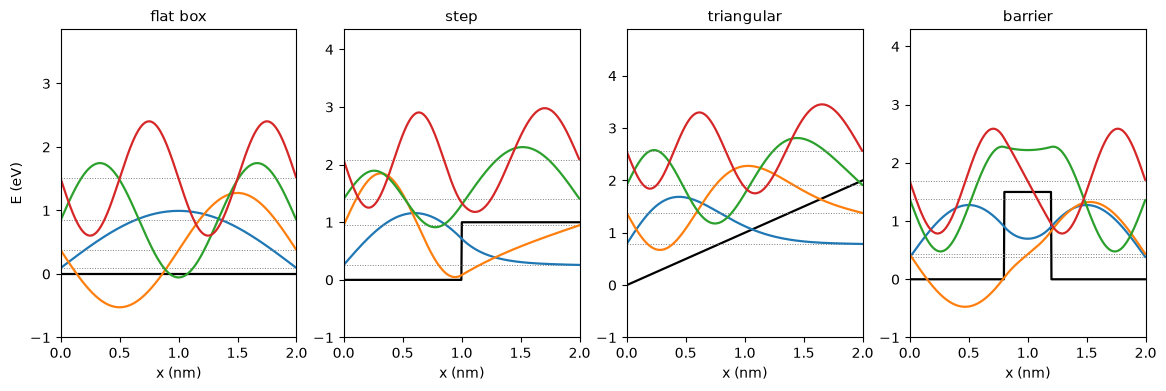

In [ ]:
L, N = 2e-9, 500

potentials = [
    ("flat box", lambda x: np.zeros_like(x)),
    ("step", lambda x: np.where(x > L / 2, 1.0 * e, 0.0)),
    ("triangular", lambda x: 2.0 * e * x / L),
    ("barrier", lambda x: np.where(np.abs(x - L / 2) < L / 10, 1.5 * e, 0.0)),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (title, Vf) in zip(axes, potentials):
    x, E, psi = solve(N, L, Vf)
    ax.plot(x * 1e9, Vf(x) / e, color="black", lw=1.6)  # 퍼텐셜
    for k in range(4):
        v = psi[:, k]
        if v[np.argmax(np.abs(v))] < 0:
            v = -v
        ax.hlines(E[k], 0, L * 1e9, color="gray", lw=0.7, ls=":")
        ax.plot(x * 1e9, E[k] + 0.9 * v / np.abs(v).max(), lw=1.6)
    ax.set_xlim(0, L * 1e9)
    ax.set_ylim(-1, E[4] + 1.5)
    ax.set_xlabel("x (nm)")
    ax.set_title(title, fontsize=11)

axes[0].set_ylabel("E (eV)")
plt.show()